# A/B Test Analysis

**Problem Statement:**

Between December 7, 2020, and January 4, 2021, an A/B test, known as the "recommender_system_test," was performed in connection with the deployment of a new payment funnel.

The anticipated outcome was a minimum 10% enhancement in each of the following key performance indicators within 14 days of user registration:

- Conversion Rate (CR) for "product_page"
- Conversion Rate (CR) for "product_cart"
- Conversion Rate (CR) for "purchase"

**Objective:**

Evaluate whether the changes associated with the implementation of an improved recommendation system for users have been beneficial.

**Research objectives:**

1. Data exploration and Data preprocessing

2. Correctness of the test

3. Exploratory Data Analysis (EDA)

4. A/B testing results evaluation

5. Conclusion

## Data Description

**/datasets/ab_project_marketing_events.csv** — a calendar of marketing events for the year 2020.

File structure:

- name — the name of the marketing event;
- regions — the regions where the advertising campaign will be conducted;
- start_dt — the start date of the campaign;
- finish_dt — the end date of the campaign.

**final_ab_new_users.csv** — users who registered from December 7th to December 21st, 2020.

File structure:

- user_id — user identifier;
- first_date — registration date;
- region — user's region;
- device — device from which the registration was performed.

**final_ab_events.csv** — actions of new users from December 7th, 2020 to January 4th, 2021.

File structure:

- user_id — user identifier;
- event_dt — event date and time;
- event_name — type of event;
- details — additional data about the event. For example, for purchases, the cost of the purchase in dollars is stored in this field.

**final_ab_participants.csv** — table of test participants.

File structure:

- user_id — user identifier;
- ab_test — test name;
- group — user group.

## Data loading and exploration

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math as mth
from scipy import stats as st 

import plotly.express as px
from plotly import graph_objects as go
import plotly.io as plt_io
from datetime import datetime 
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

import warnings                                 
warnings.filterwarnings('ignore')

In [2]:
try:
    m_events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_project_marketing_events.csv')
    events = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_events.csv')
    new_users = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_new_users.csv')
    participants = pd.read_csv('https://code.s3.yandex.net/datasets/final_ab_participants.csv')

except:
    m_events = pd.read_csv('/datasets/ab_project_marketing_events.csv')
    events = pd.read_csv('/datasets/final_ab_events.csv')
    new_users = pd.read_csv('/datasets/final_ab_new_users.csv')
    participants = pd.read_csv('/datasets/final_ab_participants.csv')

In [3]:
data_sets = [m_events, new_users, events, participants]
data_names = [
    "ab_project_marketing_events.csv",
    "final_ab_new_users.csv",
    "final_ab_events.csv",
    "final_ab_participants.csv",
]

for i, df in enumerate(data_sets):
    print(f"Dataset name: {data_names[i]}")
    print()
    df.info()
    print()
    print('exact duplicates:',df.duplicated().sum())
    display(df.sample(10))
    print()

Dataset name: ab_project_marketing_events.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   name       14 non-null     object
 1   regions    14 non-null     object
 2   start_dt   14 non-null     object
 3   finish_dt  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes

exact duplicates: 0


,name,regions,start_dt,finish_dt
6,Chinese New Year Promo,APAC,2020-01-25,2020-02-07
12,Single's Day Gift Promo,APAC,2020-11-11,2020-11-12
10,CIS New Year Gift Lottery,CIS,2020-12-30,2021-01-07
1,St. Valentine's Day Giveaway,"EU, CIS, APAC, N.America",2020-02-14,2020-02-16
2,St. Patric's Day Promo,"EU, N.America",2020-03-17,2020-03-19
4,4th of July Promo,N.America,2020-07-04,2020-07-11
5,Black Friday Ads Campaign,"EU, CIS, APAC, N.America",2020-11-26,2020-12-01
9,Victory Day CIS (May 9th) Event,CIS,2020-05-09,2020-05-11
13,Chinese Moon Festival,APAC,2020-10-01,2020-10-07
7,Labor day (May 1st) Ads Campaign,"EU, CIS, APAC",2020-05-01,2020-05-03



Dataset name: final_ab_new_users.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61733 entries, 0 to 61732
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     61733 non-null  object
 1   first_date  61733 non-null  object
 2   region      61733 non-null  object
 3   device      61733 non-null  object
dtypes: object(4)
memory usage: 1.9+ MB

exact duplicates: 0


,user_id,first_date,region,device
44799,7A731A8022ACC7BB,2020-12-18,EU,Android
49940,18EF7332ACC0D12C,2020-12-19,EU,Android
7463,10D6D212F54DF048,2020-12-14,EU,PC
40460,40AD842F0DF16C64,2020-12-11,N.America,Android
51149,28EB274BF69841A8,2020-12-19,EU,Android
50431,9615DFB754655C2B,2020-12-19,N.America,PC
24146,49114E761FB55756,2020-12-22,EU,Mac
22220,8244B488084822F8,2020-12-15,EU,iPhone
8609,04866EB5A02B9D32,2020-12-14,CIS,Android
41038,755437266D1444FF,2020-12-11,N.America,Mac



Dataset name: final_ab_events.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440317 entries, 0 to 440316
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   user_id     440317 non-null  object 
 1   event_dt    440317 non-null  object 
 2   event_name  440317 non-null  object 
 3   details     62740 non-null   float64
dtypes: float64(1), object(3)
memory usage: 13.4+ MB

exact duplicates: 0


,user_id,event_dt,event_name,details
336737,3A882F70DA910384,2020-12-18 18:45:34,login,NaN
355110,64D69EAC8EBA6317,2020-12-20 04:24:41,login,NaN
286530,C3C56A2DFF10BC79,2020-12-13 04:41:30,login,NaN
32049,AF199ED3ED55ECD1,2020-12-19 16:30:28,purchase,4.99
33726,C33EB86CCDCF61B8,2020-12-19 14:15:16,purchase,4.99
111007,52E972D9039F3D42,2020-12-23 03:47:20,product_cart,NaN
388492,1B83AE44E1A7D58F,2020-12-22 08:20:51,login,NaN
375589,0A6CF2C8602CC7EB,2020-12-21 05:07:23,login,NaN
178196,1E0687A2F6A182ED,2020-12-17 20:09:23,product_page,NaN
60393,BD390BC84412524D,2020-12-28 00:33:49,purchase,4.99



Dataset name: final_ab_participants.csv

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  18268 non-null  object
 1   group    18268 non-null  object
 2   ab_test  18268 non-null  object
dtypes: object(3)
memory usage: 428.3+ KB

exact duplicates: 0


,user_id,group,ab_test
12649,A35E3C69104F9692,A,interface_eu_test
5728,C9985A184A2C0CAF,A,recommender_system_test
2826,DD155919BA4AC26E,A,recommender_system_test
18083,D624C989E3231875,B,interface_eu_test
9445,C8D9382EFC3221EF,A,interface_eu_test
9575,65C4D9746EDEDE88,B,interface_eu_test
17833,3BCDEB8F5A891D30,A,interface_eu_test
10637,156F535CE0778E11,A,interface_eu_test
11536,C521F9B28999D38C,A,interface_eu_test
14891,C9A519529D0EFC40,A,interface_eu_test


ab_project_marketing_events.csv:

- no missing data.
- all columns are comprised of text data, except for the "start_dt" and "finish_dt" columns, which exclusively contain date values.
- no exact duplicates are present within the dataset.
- the column names have been appropriately assigned and match the expected format.

final_ab_new_users.csv:

- no missing data.
- all columns are comprised of text data, except for the first_date, which exclusively contain date values.
- no exact duplicates are present within the dataset.
- the column names have been appropriately assigned and match the expected format.

final_ab_events.csv:

- missing data in the "details" column.
- 3 columns are comprised of text data, except for the "event_dt", which exclusively contain date values.
- there is one floating-point column representing the purchase amounts, which is considered typical. However, further investigation is necessary to analyze the values within this column with respect to the event types.
- no exact duplicates are present within the dataset.
- the column names have been appropriately assigned and match the expected format.

final_ab_participants.csv:

- no missing data.
- all columns are comprised of text data.
- no exact duplicates are present within the dataset.
- the column names have been appropriately assigned and match the expected format.

### Data preprocessing

### Changing Data Types

In [4]:
m_events['start_dt'] = pd.to_datetime(m_events['start_dt']) 
m_events['finish_dt'] = pd.to_datetime(m_events['finish_dt']) 
new_users['first_date'] = pd.to_datetime(new_users['first_date']) 
events['event_dt'] = pd.to_datetime(events['event_dt'])

### Table "events"

In [5]:
print('Number of duplicates :', sum(events.duplicated()))

Number of duplicates : 0


In [6]:
print('Min event date:', events['event_dt'].min())
print('Max evemt date:',  events['event_dt'].max())

Min event date: 2020-12-07 00:00:33
Max evemt date: 2020-12-30 23:36:33


In [7]:
events['details'].unique()

array([ 99.99,   9.99,   4.99, 499.99,    nan])

In [8]:
events.groupby('event_name', as_index=False).agg({'details': 'min'})

,event_name,details
0,login,NaN
1,product_cart,NaN
2,product_page,NaN
3,purchase,4.99


The events table comprises 440,317 records and 4 columns.

The data type of the "event_dt" column has been converted from "object" to "date."

The table's data covers the period from December 7 to December 30, 2020. However, it was expected, as per the technical specifications, to encompass data from December 7, 2020, to January 4, 2021. This discrepancy may suggest that the test concluded prematurely or that not all available data was loaded.

Gaps within the "details" column are noteworthy. This column provides information about the purchase amount and is exclusively available for transaction records that pertain to purchases. Empty entries within this column for events (purchases) signify a lack of information about those specific events.

### Table "m_events"

In [9]:
print('Number of duplicates :', sum(m_events.duplicated()))

Number of duplicates : 0


In [10]:
print('Min date:', m_events['start_dt'].min())
print('Max date:',  m_events['finish_dt'].max())

Min date: 2020-01-25 00:00:00
Max date: 2021-01-07 00:00:00


In [11]:
m_events['regions'].value_counts()

APAC                        4
EU, CIS, APAC, N.America    3
EU, N.America               2
EU, CIS, APAC               2
CIS                         2
N.America                   1
Name: regions, dtype: int64

All marketing events:

In [12]:
m_events['name'].value_counts()

Christmas&New Year Promo            1
St. Valentine's Day Giveaway        1
St. Patric's Day Promo              1
Easter Promo                        1
4th of July Promo                   1
Black Friday Ads Campaign           1
Chinese New Year Promo              1
Labor day (May 1st) Ads Campaign    1
International Women's Day Promo     1
Victory Day CIS (May 9th) Event     1
CIS New Year Gift Lottery           1
Dragon Boat Festival Giveaway       1
Single's Day Gift Promo             1
Chinese Moon Festival               1
Name: name, dtype: int64

The "m_events" table has 14 rows, 4 columns.

No missing data or exact duplicates.
The data type of the "first_date" column has been converted to "datetime."

### Table "new_users"

In [13]:
print('Number of duplicates :', sum(new_users.duplicated()))

Number of duplicates : 0


In [14]:
print('Min date:', new_users['first_date'].min())
print('Max date:',  new_users['first_date'].max())

Min date: 2020-12-07 00:00:00
Max date: 2020-12-23 00:00:00


The table contains information about new users added to test groups within the time frame of December 7 to December 23, 2020. However, as per the project assignment, the expected data should cover the period from December 7 to December 21, 2020. This discrepancy likely arose due to an erroneous data upload request. It is necessary to apply a data filter to align the dataset with the specified time frame.

In [15]:
new_users = new_users[new_users['first_date'] <= '2020-12-21 00:00:00']

In [16]:
new_users['region'].value_counts()

EU           42340
N.America     8347
CIS           2900
APAC          2883
Name: region, dtype: int64

The table contains regions other than the “Europe” region, since we won’t need them to check the test results; we’ll filter the data.

In [17]:
new_users = new_users[new_users['region'] == 'EU']

The new_users table contains 61,733 records and 4 columns.

There are no gaps or duplicates.

The data type in the "first_date" column has been converted to datetime format.

According to the statement of work, the recruitment of new users was completed on December 21, 2020, therefore all rows with a date later than the specified one were removed from the dataset.

The table contains data for regions other than "Europe". However, for the purpose of validating test results, we do not require data for regions other than "Europe", so all records not related to this region have been removed.

### Table "participants"

In [18]:
print('Number of duplicates :', sum(participants.duplicated()))

Number of duplicates : 0


In [19]:
participants.groupby(['ab_test', 'group']).agg({'user_id': 'nunique'})

user_id
ab_test                 group         
interface_eu_test       A         5831
                        B         5736
recommender_system_test A         3824
                        B         2877

The "participants" table has 18268 rows and 3 columns.

No gaps or duplicates.

Data types are correctly specified.

The dataset contains information on two distinct tests, but for the purposes of the study, it is imperative to focus exclusively on one of them, namely, the "recommender_system_test."

**In a summary statement:**

- We conducted data analysis across four tables.

- We appropriately adjusted data types for columns containing date and time information.

- No duplicates were found within the dataset.

- It's noteworthy that the "events" table reports data spanning from December 7 to December 30, 2020, despite the project requirement for data covering the period from December 7, 2020, to January 4, 2021. This suggests that the testing phase may have concluded prematurely or that there were issues with the successful loading of all the required data.

- In the events table, gaps were identified in the "details" column, which contains information about purchase amounts. This information is available only for purchase transactions, and the missing data cannot be filled because other event information is absent.

- According to the technical specifications, the deadline for recruiting new users was December 21, 2020. Therefore, all records with dates beyond this cutoff were removed from the new_users table.

- Non-"EU" regions were discovered in the new_users table. However, for the purpose of verifying test results, this data is unnecessary, so all entries not corresponding to the "EU" region have been eliminated.

## Correctness of the test

We'll combine the data necessary for analysis. Users from the EU region in the new_users table and data on test participants from the participants table

In [20]:
data = new_users.merge(participants, on='user_id', how='left').dropna()

In [21]:
data.head()

,user_id,first_date,region,device,group,ab_test
0,D72A72121175D8BE,2020-12-07,EU,PC,A,recommender_system_test
1,2E1BF1D4C37EA01F,2020-12-07,EU,PC,A,interface_eu_test
2,50734A22C0C63768,2020-12-07,EU,iPhone,B,interface_eu_test
7,E6DE857AFBDC6102,2020-12-07,EU,PC,B,recommender_system_test
8,E6DE857AFBDC6102,2020-12-07,EU,PC,B,interface_eu_test


In [22]:
data['ab_test'].value_counts()

interface_eu_test          10565
recommender_system_test     6351
Name: ab_test, dtype: int64

Number of test participants recommender_system_test 6351

In [23]:
data_new = data.query('ab_test=="recommender_system_test"& region == "EU"')

print('Share of new users from the EU region: {:.0%}'.format (len(data_new)/len(new_users)))

Share of new users from the EU region: 15%


The test audience is 15% of new users from the EU region

### Verifying the intersections of events with marketing and other activities.

In [24]:
m_events_eu = (m_events[
    m_events['regions'].str.contains('EU')])

In [25]:
m_events_eu[(m_events_eu['start_dt'] >= '2020-12-07 00:00:00') & (m_events_eu['start_dt'] <= '2020-12-30 23:59:59')]


,name,regions,start_dt,finish_dt
0,Christmas&New Year Promo,"EU, N.America",2020-12-25,2021-01-03


One of the marketing campaigns coincides with the A/B testing. This may affect the correctness of the test results, since before the New Year, buyers react more actively to promotions.

### Verifying the intersection of applications of two tests

In [26]:
test_cross = (data_new['user_id'].reset_index().merge(
 participants[participants['ab_test'] == 'interface_eu_test']['user_id'].reset_index(),
     how='inner', on='user_id'))

In [27]:
print('{} users participated in both tests'.format(len(test_cross)))

1602 users participated in both tests


In [28]:
print('{:.2%} users participated in both tests'.
      format(len(test_cross) /
             len(data_new['user_id'])))

25.22% users participated in both tests


Verifying if overlapping users are evenly distributed between the groups of our test

In [29]:
print(test_cross.merge(
 participants[participants['ab_test'] ==
                    'recommender_system_test']
    [['user_id', 'group']], how='left',
    on='user_id')['group'].value_counts()
      /
      (data_new.merge(participants[participants['ab_test'] == 
                          'recommender_system_test']
                      [['user_id', 'group']]))['group'].value_counts())

A    0.253440
B    0.250644
Name: group, dtype: float64


Overlapping users are distributed evenly across groups; we will leave them as the results of our test will not be distorted.

### Verifying the uniform distribution of users across test groups and the accuracy of their assignment methodology

In [30]:
data_new_group = pd.DataFrame()
data_new_group=data_new.groupby('group', as_index=False).agg(count=('group', 'count')).sort_values(by='count',ascending=False)
data_new_group['percent'] = ((data_new_group['count'] / data_new_group['count'].sum()).map('{:.2%}'.format))

data_new_group

,group,count,percent
0,A,3634,57.22%
1,B,2717,42.78%


Users in groups are unevenly divided:

57% in group A

43% in group B

In [31]:
(len(set(data_new.query('group == "A"')['user_id'].unique()).
 intersection(set(data_new.query('group == "B"')['user_id'].unique()))))

0

Users in groups A and B do not overlap.

### Verifying the event period

Verifying whether all events fit within the period of 14 days.

In [32]:
data_events = data_new[['user_id', 'group']].merge(events, how='left', on='user_id')

In [33]:
data_events.nunique()

user_id        6351
group             2
event_dt      15628
event_name        4
details           4
dtype: int64

In [34]:
data_events = data_events.merge(new_users[['user_id', 'first_date']], how='left', on='user_id')
data_events1 = data_events[(data_events['event_dt'] - data_events['first_date']).dt.days <= 13]
print(data_events1.nunique())
('Number of users who performed actions within a 14-day period after registration : {}'.format( len(data_events1['user_id'].unique())))

user_id        3481
group             2
event_dt      15092
event_name        4
details           4
first_date       15
dtype: int64


'Number of users who performed actions within a 14-day period after registration : 3481'

Conclusion:

- We conducted an evaluation of the test execution's accuracy.

- The count of participants in the "recommender_system_test" is 6351, slightly exceeding the specified 6000 in the technical specifications.

- The test cohort comprises 15% of new users from the EU region, aligning with the specified parameters.

- Notably, one marketing campaign coincided with the A/B testing timeframe. This temporal overlap may potentially influence the test result reliability, especially considering heightened buyer responsiveness to promotions before the New Year.

- It was observed that 1602 users (25.22%) were involved in both tests, potentially impacting the independence of the results.

- The user distribution between the test and control groups appears uneven, with a ratio of 57% to 43%, warranting further scrutiny.

- Out of the 6351 registered users involved in the test, 3481 completed actions within the 14-day period following registration.

## Exploratory data analysis

### Distribution of the number of events per user in samples

In [35]:
tests_group = data_events1.groupby(['user_id', 'group'])['event_name'].count().reset_index()
tests_group.groupby('group')['event_name'].agg(['mean', 'median','max','min'])

,mean,median,max,min
group,,,,
A,6.849078,6.0,24,1
B,5.456100,4.0,24,1


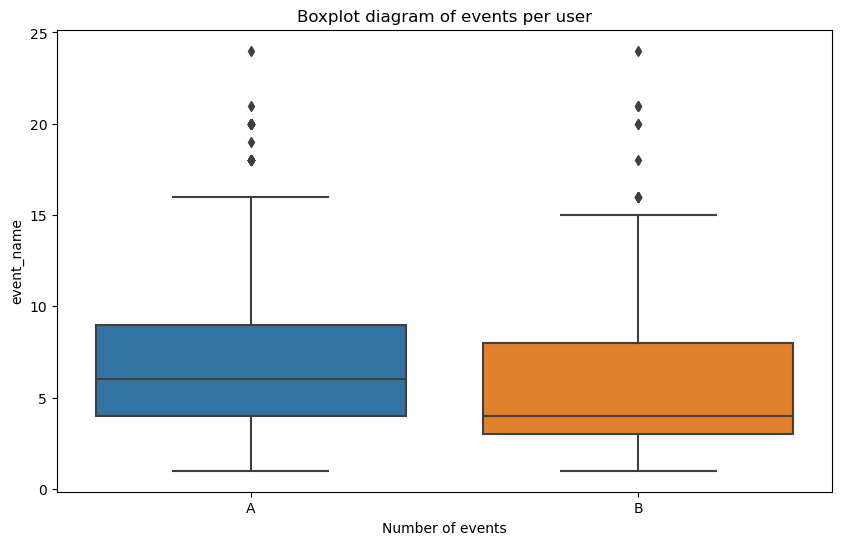

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=tests_group, y='event_name', x='group', order=['A', 'B'])
plt.title('Boxplot diagram of events per user')
plt.xlabel('Number of events')
plt.show()

The median count of events per user in Group A is recorded at 6 events, while Group B exhibits a median of 4 events. It is evident from the data that there has been a decline in activity subsequent to the implementation of the changes. The graphical representation indicates that the minimum and maximum event counts per user in both groups (A and B) are identical, yet the median value in Group A surpasses that of Group B.

### Distribution of the number of events by day

In [37]:
data_events1['date'] = data_events1['event_dt'].dt.date

In [38]:
data_events1.head()

,user_id,group,event_dt,event_name,details,first_date,date
0,D72A72121175D8BE,A,2020-12-07 21:52:10,product_page,NaN,2020-12-07,2020-12-07
1,D72A72121175D8BE,A,2020-12-07 21:52:07,login,NaN,2020-12-07,2020-12-07
3,DD4352CDCF8C3D57,B,2020-12-07 15:32:54,product_page,NaN,2020-12-07,2020-12-07
4,DD4352CDCF8C3D57,B,2020-12-08 08:29:31,product_page,NaN,2020-12-07,2020-12-08
5,DD4352CDCF8C3D57,B,2020-12-10 18:18:27,product_page,NaN,2020-12-07,2020-12-10


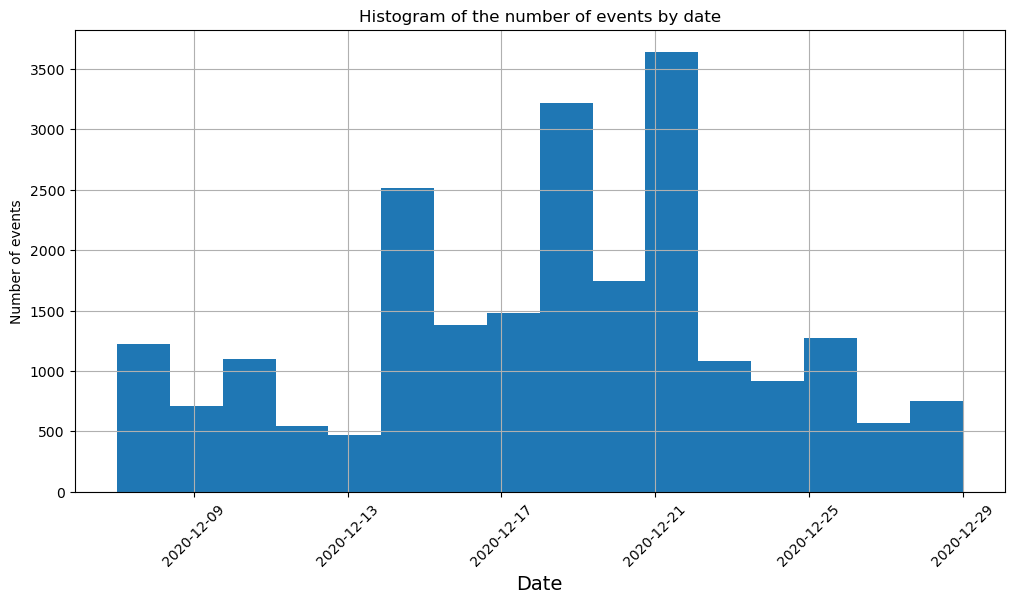

In [39]:
plt.figure(figsize =(12, 6))
data_events1['date'].hist(
                bins=16
                )
plt.title('Histogram of the number of events by date')
plt.xticks(rotation=45)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of events')
plt.show()

An increase in the activity of the test audience is observed from December 14 to 20, and after December 21 there is a decline.

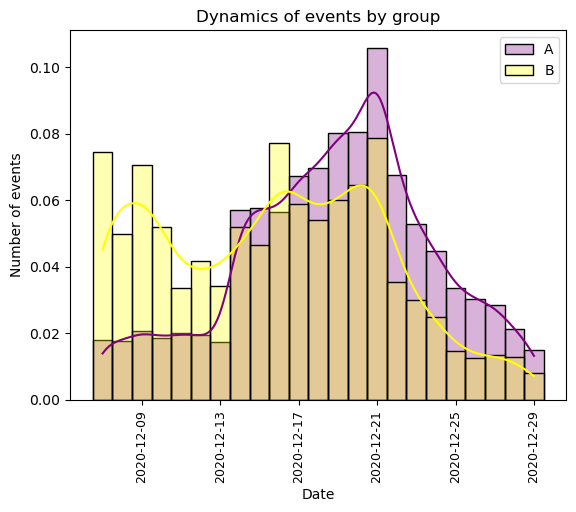

In [40]:
sns.histplot(data_events1.query('group == "A"')['date'], color='purple',\
             alpha=0.3, label='A',bins=(data_events1['date'].max() - data_events1['date'].\
                                        min()).days, kde=True, stat='density')
sns.histplot(data_events1.query('group == "B"')['date'], color='yellow',\
             alpha=0.3, label='B',bins=(data_events1['date'].max() - data_events1['date'].\
                                        min()).days, kde=True, stat='density')
plt.title('Dynamics of events by group')
plt.ylabel('Number of events')
plt.xlabel('Date')
plt.tick_params(axis='x',labelsize=9,labelrotation=90)
plt.legend()
plt.show()

The chart illustrates that activity maintained a low level until December 13th, after which it started to ascend, reaching its peak around December 21st, followed by a decline for the remainder of the year. Although the overall trends in both groups were similar, Group B displayed a notably more active outset during the initial period. Towards the year-end, there was a decline in activity observed in both Group A and Group B.

### Conversion in the funnel at different stages

Verifying what events are in the logs and how often they occur. Sorting events by frequency.

In [41]:
data_events1['event_name'].value_counts()

login           10217
product_page     6322
purchase         3103
product_cart     2978
Name: event_name, dtype: int64

In [42]:
data_events1_group = data_events1.pivot_table(index='event_name', columns='group', values='user_id', aggfunc='nunique')\
.reset_index()
data_events1_group

group,event_name,A,B
0,login,2604,876
1,product_cart,782,244
2,product_page,1685,493
3,purchase,833,249


Correct sequence of events:

1. login
2. product_page
3. product_cart
4. purchase


In [43]:
data_events1_group = data_events1.pivot_table(index='event_name', columns='group', values='user_id', aggfunc='nunique')\
.reset_index().reindex([0, 2, 1, 3])

In [44]:
data_events1_group

group,event_name,A,B
0,login,2604,876
2,product_page,1685,493
1,product_cart,782,244
3,purchase,833,249


In [46]:
data_events1_group_reset = data_events1_group.reset_index()

fig = go.Figure()


fig.add_trace(go.Funnel(
    name='A',
    y=data_events1_group_reset['event_name'],
    x=data_events1_group_reset['A'],
    marker={'color': 'purple'},
    textinfo="value+percent previous+percent initial"
))


fig.add_trace(go.Funnel(
    name='B',
    orientation="h",
    y=data_events1_group_reset['event_name'],
    x=data_events1_group_reset['B'],
    marker={'color': 'yellow'},
    textposition="auto",
    textinfo="value+percent previous+percent initial"
))


fig.update_layout(
    autosize=False,
    width=900,
    height=400,
    margin=go.layout.Margin(l=50, r=50, b=0, t=50, pad=4),
    template="plotly_white",
    title='Event Funnel',
    title_x=0.50
)

fig.show()

In Group A, the count of purchases surpasses that of cart views by more than 2%. This discrepancy is possibly a result of one-click ordering methods that bypass the necessity for accessing the cart. The conversion rate to purchase stands at 32% in Group A, slightly higher than the 28% observed in Group B. Nevertheless, after users initiate the login process, Group A experiences a 35% loss, where users do not proceed to view the product. Conversely, Group B encounters a higher loss rate, amounting to 44%, signifying a greater drop-off in user engagement post-login.

Looking at the event funnel of the number of all participants in each group of the A/B test

In [47]:
data_events1_group = (data_events1_group.append(pd.DataFrame(data={'event_name': ['all'], 
                   'A':[len(data_new[data_new['group']=='A'])], 
                   'B':[len(data_new[data_new['group']=='B'])]}))
                    .reset_index())

In [48]:
data_events1_group = data_events1_group.drop('index', axis=1)

data_events1_group

,event_name,A,B
0,login,2604,876
1,product_page,1685,493
2,product_cart,782,244
3,purchase,833,249
4,all,3634,2717


In [49]:
data_events1_group['conversion_a'] = round(data_events1_group['A'] / data_events1_group.loc[data_events1_group['event_name'] == 'all', 'A'].values[0],2)
data_events1_group['conversion_b'] = round(data_events1_group['B'] / data_events1_group.loc[data_events1_group['event_name'] == 'all', 'B'].values[0],2)

In [50]:
data_events1_group

,event_name,A,B,conversion_a,conversion_b
0,login,2604,876,0.72,0.32
1,product_page,1685,493,0.46,0.18
2,product_cart,782,244,0.22,0.09
3,purchase,833,249,0.23,0.09
4,all,3634,2717,1.00,1.00


In [51]:
data_events1_group = data_events1_group.reindex([4,0,1,2,3])

Creating an event funnel

In [52]:
fig = go.Figure()

fig.add_trace(go.Funnel(
    name = 'A',
    y = data_events1_group.reset_index()['event_name'],
    x = data_events1_group.reset_index()['A'],
    marker = {'color': 'blue'},
    textinfo = "value+percent previous+ percent initial"))

fig.add_trace(go.Funnel(
    name = 'B',
    orientation = "h",
    y = data_events1_group.reset_index()['event_name'],
    x = data_events1_group.reset_index()['B'],
    marker = {'color': 'pink'},
    textposition = "auto",
    textinfo = "value+percent previous+ percent initial"))

fig.update_layout(autosize=False, width=900, height=400, 
                  margin=go.layout.Margin(l=50, r=50, b=0, t=50, pad=4))
fig.layout.template = plt_io.templates["plotly_white"]
fig.update_layout(title='Funnel of events from the total number of group members', title_x=0.50)
fig.show()


Within the specified timeframe and aligned with technical requirements, 72% of users in Group A initiated a login, contrasting with 32% in Group B who followed the same action. Subsequent to logging in, 65% of Group A users and 56% of Group B users proceeded to view the product page, constituting a proportion of the total logged-in user count. However, in terms of purchase conversion, Group A demonstrates a substantial conversion rate of 23%, notably surpassing Group B's conversion rate of merely 9%.

Conclusion:

- Group A exhibits a median event count per user of 6, while Group B's median stands at 4 events.

- Test audience activity witnessed a surge from December 14 to 20, followed by a subsequent decline after December 21.

- All conversion rates among the total test participants in Group B are inferior in comparison to those in Group A.

- Notably, the conversion to purchase in Group A attains a significant rate of 23%, distinctly surpassing the notably lower 9% in Group B.

### What data features should we consider before starting A/B testing?

Criteria for a successful A/B test:

- **Balanced Group Sizes:** Ensure a balanced distribution of users between the control and test groups, ideally with a minimal difference not exceeding 1%.

- **Experiment Duration:** Adhere to the planned duration of the experiment, ideally lasting at least 2 weeks to capture sufficient data and trends.

- **Isolation from Other Activities:** Avoid overlap between the ongoing test and any concurrent experiments or marketing activities to prevent interference or influence on test outcomes.

- **Statistical Consistency:** Verify that key metrics between the control and test groups display no statistically significant differences, aiming for a difference of no more than 1%. This ensures a fair comparison between groups and valid interpretation of results.

- Ensure continuity for visitors assigned to a specific group throughout the test duration. If a user encounters different versions of the page under examination within the same study period, it becomes challenging to ascertain the precise influence of each version on their decisions, leading to ambiguous results.

- Eliminate surplus or extraneous samples to attain statistically significant testing outcomes. Removing unnecessary or irrelevant samples from the dataset helps in achieving more accurate and reliable test results.

## A/B testing results evaluation

- During testing, data was inaccurately collected from December 7 to December 23, 2020, despite the planned conclusion of user recruitment by December 21.

- The collected dataset includes users not solely from the EU region but also from various other regions.

- While the intended test duration spanned from December 7, 2020, to January 4, 2021, the available data extends only up to December 30, 2020, resulting in a data gap for the final 5 days of the test period.

- The testing timeframe coincided with the "Christmas & New Year Promo" marketing event for 5 days, potentially influencing the study's outcomes.

- Additionally, the test encompassed users involved in a competing experiment, amounting to 1602 individuals (25.22%).

- The anticipated 10% improvement in conversion rates was not realized. Group A exhibited a purchase conversion rate of 23%, significantly surpassing Group B, which achieved only 9%.

- The data collection process or overall site functionality might have been impacted by a potential technical malfunction. Consequently, the obtained data might not be conducive to drawing conclusions regarding the A/B test. The nature of this failure could potentially be associated with the execution of a concurrent test.

In [53]:
data_events1_group

,event_name,A,B,conversion_a,conversion_b
4,all,3634,2717,1.00,1.00
0,login,2604,876,0.72,0.32
1,product_page,1685,493,0.46,0.18
2,product_cart,782,244,0.22,0.09
3,purchase,833,249,0.23,0.09


Conversions for each event are lower in group B.

### Assessing the statistical variance in proportions through the z-test.

Performing Z-statistics computation to evaluate the significance of proportions between two distinct samples, A and B.

To evaluate the hypotheses, we will utilize the Z-test and implement the Bonferroni correction method due to multiple comparisons. Specifically, in our scenario, we'll conduct 4 comparisons, thus setting the Bonferroni adjusted alpha as alpha / 4.

In [54]:
def z_test(a, b, df,  alpha):    
    print('H0: The event proportions {} in groups {} and {} are identical'.format(event, a, b))
    print('H1: The event proportions {} in groups {} and {} are different'.format(event, a, b))
    
    successes = [df.loc[event][a], df.loc[event][b]]
    trials = [df.loc['all'][a], df.loc['all'][b]]
    
    p1 = successes[0]/trials[0]
    p2 = successes[1]/trials[1]
    p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])
    difference = p1 - p2 
    
    z_value = difference / mth.sqrt(p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1]))
    
    distr = st.norm(0, 1)
    p_value = (1 - distr.cdf(abs(z_value))) * 2
    
    print('p-value: ', round(p_value, 5))
    if p_value < alpha:
        print('Rejectng the null hypothesis, indicating a distinction between the proportions.'.
             format(event, a, b))
    else:
        print('Failing to reject the null hypothesis'.format(event, a, b))
    print()

In [55]:
data_events1_group.set_index('event_name', inplace=True)

In [56]:
for event in ['login', 'product_page', 'product_cart', 'purchase']:
    z_test('A', 'B', data_events1_group, .05/4)

H0: The event proportions login in groups A and B are identical
H1: The event proportions login in groups A and B are different
p-value:  0.0
Rejectng the null hypothesis, indicating a distinction between the proportions.

H0: The event proportions product_page in groups A and B are identical
H1: The event proportions product_page in groups A and B are different
p-value:  0.0
Rejectng the null hypothesis, indicating a distinction between the proportions.

H0: The event proportions product_cart in groups A and B are identical
H1: The event proportions product_cart in groups A and B are different
p-value:  0.0
Rejectng the null hypothesis, indicating a distinction between the proportions.

H0: The event proportions purchase in groups A and B are identical
H1: The event proportions purchase in groups A and B are different
p-value:  0.0
Rejectng the null hypothesis, indicating a distinction between the proportions.



Upon assessing the outcomes of the A/B test, we compared the proportions between two samples, A and B, revealing statistically significant disparities. It is evident that the event proportions within Group A and Group B differ.

## Conclusion

The test outcomes fail to adhere to standard A/B testing criteria, rendering them unsuitable for drawing conclusions due to violations of critical experiment components.

**Main issues:**

- Data collection spanned from December 7 to December 23, 2020, surpassing the planned user recruitment end date of December 21.

- The dataset contains users not solely from the EU region but also from other regions, leading to result distortions.

- The intended test duration was December 7, 2020, to January 4, 2021, yet data is only available until December 30, 2020, leaving a 5-day data gap at the end.

- The test coincided with the "Christmas&New Year Promo" marketing event for 5 days, potentially impacting experiment outcomes.

- Inclusion of 1602 users (25.22%) from a concurrent test.

- The user distribution between groups was non-uniform.

**Based on the above issues, the following recommendations are offered:**

- Exercise utmost diligence during data collection when conducting retests.

- Refrain from conducting concurrent tests that may compete or interfere with each other.

- Account for the influence of marketing events on test outcomes and consider conducting experiments during alternative time frames.

- Strive for an equitable distribution between the test and control groups to ensure balanced comparisons.